# SVC

In [24]:
import pandas as pd
import numpy as np

In [25]:
from sklearn.datasets import load_iris

In [50]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head(15)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [53]:
print("Target Names:", iris.target_names)

Target Names: ['setosa' 'versicolor' 'virginica']


In [51]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [30]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [31]:
df["target"].value_counts()

,count
target,
0,50
1,50
2,50


In [56]:
df["flower_name"] = df["target"].map({0: "setosa",1: "versicolor",2: "virginica"})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [62]:
X = df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]]
y = df["target"]

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("CM:\n", confusion_matrix(y_test, y_pred))
print()
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

CM:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [66]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# sirf class 0 aur 1 le
mask = y < 2
X = X[mask]
y = y[mask]

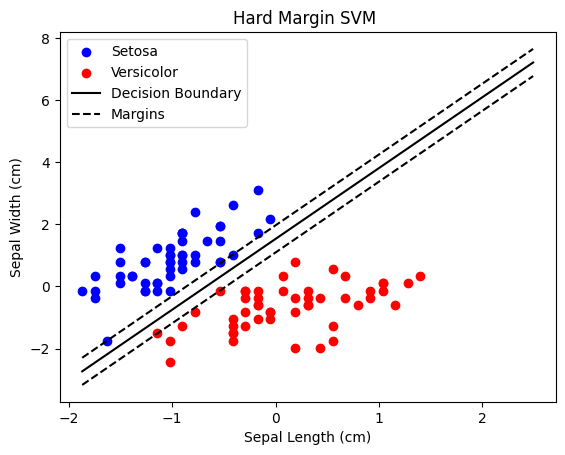

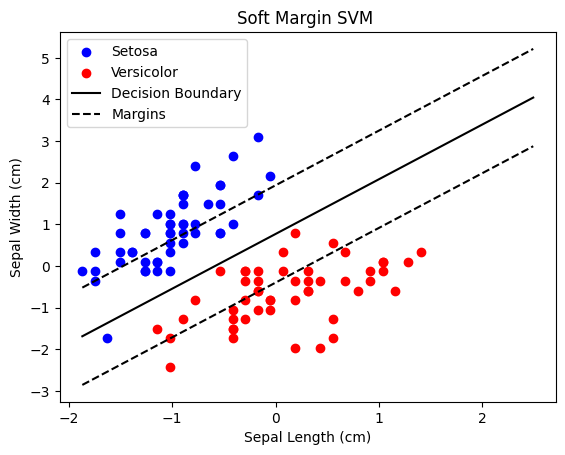

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = df[['sepal length (cm)', 'sepal width (cm)']].values
y = df['target'].values

class_names = ['Setosa', 'Versicolor']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hard_model = SVC(kernel='linear', C=1000)
soft_model = SVC(kernel='linear', C=0.1)

hard_model.fit(X_scaled, y)
soft_model.fit(X_scaled, y)


def plot_svm(model, X, y, title):
    plt.figure()


     # Plot points with names
    colors = ['blue', 'red']
    for i, name in enumerate(class_names):
        plt.scatter(X[y == i, 0], X[y == i, 1],
                    label=name, color=colors[i])


   # decision boundary
    w = model.coef_[0]
    b = model.intercept_[0]

    x_points = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_points = -(w[0]*x_points + b) / w[1]

    y_margin1 = -(w[0]*x_points + b - 1) / w[1]
    y_margin2 = -(w[0]*x_points + b + 1) / w[1]

    plt.plot(x_points, y_points, 'k-', label='Decision Boundary')
    plt.plot(x_points, y_margin1, 'k--', label='Margins')
    plt.plot(x_points, y_margin2, 'k--')

    # Labels
    plt.xlabel("Sepal Length (cm)")
    plt.ylabel("Sepal Width (cm)")

    plt.title(title)
    plt.legend()
    plt.show()


plot_svm(hard_model, X_scaled, y, "Hard Margin SVM ")
plot_svm(soft_model, X_scaled, y, "Soft Margin SVM ")